In [15]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_val_pred_hgb = hgb.predict(X_val)
y_val_proba_hgb = hgb.predict_proba(X_val)[:, 1]

y_val_pred_rf = rf.predict(X_val)
y_val_proba_rf = rf.predict_proba(X_val)[:, 1]


metrics = pd.DataFrame({
    'Modell': ['HistGradientBoosting', 'Random Forest'],
    'Precision': [
        precision_score(y_val, y_val_pred_hgb),
        precision_score(y_val, y_val_pred_rf)
    ],
    'Recall': [
        recall_score(y_val, y_val_pred_hgb),
        recall_score(y_val, y_val_pred_rf)
    ],
    'F1': [
        f1_score(y_val, y_val_pred_hgb),
        f1_score(y_val, y_val_pred_rf)
    ],
    'PrecisionRecall-AUC': [
        average_precision_score(y_val, y_val_proba_hgb),
        average_precision_score(y_val, y_val_proba_rf)
    ]})

display(metrics)

,Modell,Precision,Recall,F1,PrecisionRecall-AUC
0,HistGradientBoosting,0.571429,0.648649,0.607595,0.500252
1,Random Forest,0.964912,0.743243,0.839695,0.817762


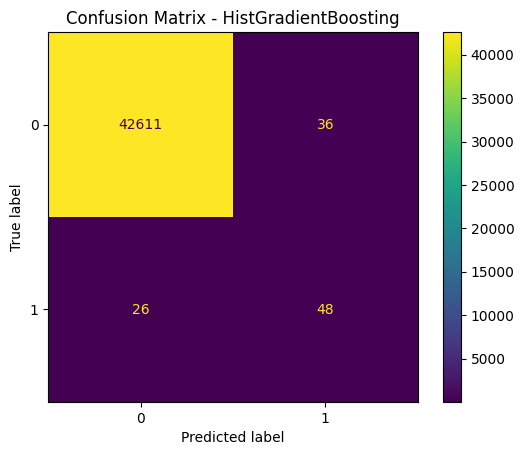

In [16]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_hgb)
plt.title("Confusion Matrix - HistGradientBoosting")
plt.show()

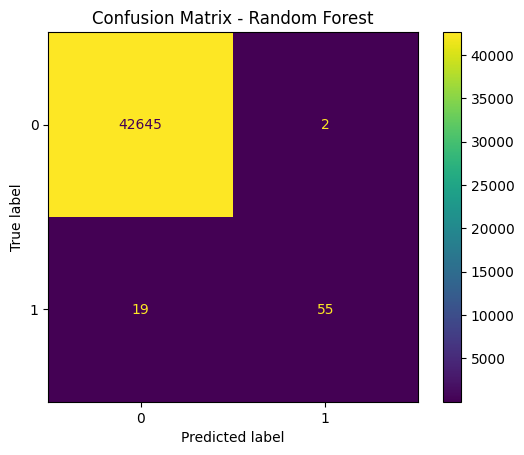

In [17]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_rf)
plt.title("Confusion Matrix - Random Forest")
plt.show()

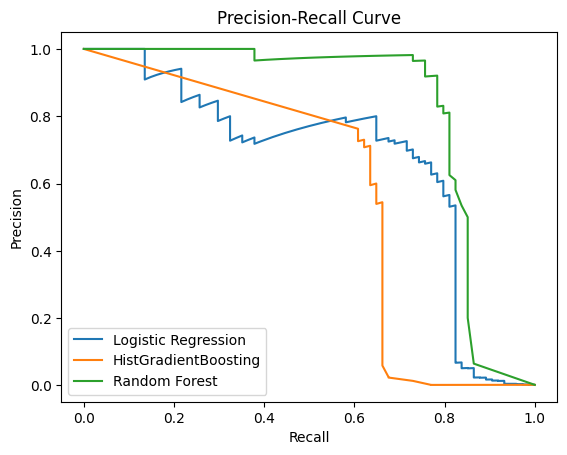

In [18]:
p_lr, r_lr, _ = precision_recall_curve(y_val, y_val_prob)
p_hgb, r_hgb, _ = precision_recall_curve(y_val, y_val_proba_hgb)
p_rf, r_rf, _ = precision_recall_curve(y_val, y_val_proba_rf)

plt.plot(r_lr,  p_lr,  label='Logistic Regression')
plt.plot(r_hgb, p_hgb, label='HistGradientBoosting')
plt.plot(r_rf,  p_rf,  label='Random Forest')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()